# A full distributed training loop

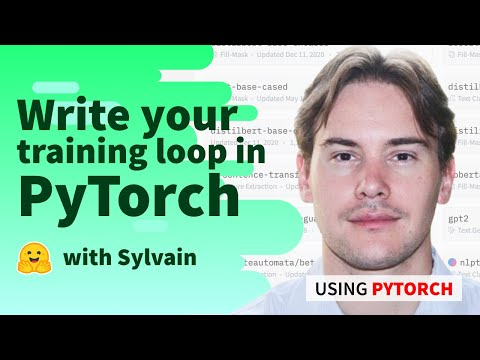

In [1]:
from IPython.display import YouTubeVideo

YouTubeVideo("Dh9CL8fyG80", width=800, height=450)

Now we’ll see how to achieve the same results as we did in the last section without using the Trainer class, implementing a training loop from scratch with modern PyTorch best practices. Again, we assume you have done the data processing in section 2. Here is a short summary covering everything you will need:

> 🏗️ Training from Scratch: This section builds on the previous content. For comprehensive guidance on PyTorch training loops and best practices, check out the [🤗 Transformers training documentation](https://huggingface.co/docs/transformers/main/en/training#train-in-native-pytorch) and the [custom training cookbook](https://huggingface.co/learn/cookbook/en/fine_tuning_code_llm_on_single_gpu#model).

In [2]:
from datasets import load_dataset

raw_datasets = load_dataset("nyu-mll/glue", "mrpc")

In [3]:
from transformers import AutoTokenizer

ckpt = "bert-base-uncased"

tokenizer = AutoTokenizer.from_pretrained(ckpt)

In [4]:
tokenized_datasets = raw_datasets.map(
    lambda x: tokenizer(x['sentence1'], x['sentence2'], truncation=True), 
    batched=True
)
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['sentence1', 'sentence2', 'label', 'idx', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

In [5]:
from transformers import DataCollatorWithPadding

data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer,
    padding=True,
    pad_to_multiple_of=8
)

## Prepare for training

Before actually writing our training loop, we will need to define a few objects. The first ones are the dataloaders we will use to iterate over batches. But before we can define those dataloaders, we need to apply a bit of postprocessing to our `tokenized_datasets`, to take care of some things that the `Trainer` did for us automatically. Specifically, we need to:

- Remove the columns corresponding to values the model does not expect (like the `sentence1` and `sentence2` columns).
- Rename the column `label` to `labels` (because the model expects the argument to be named `labels`).
- Set the format of the datasets so they return PyTorch tensors instead of lists.

Our `tokenized_datasets` has one method for each of those steps:

**Remove Columns:**

In [6]:
tokenized_datasets = tokenized_datasets.remove_columns(["sentence1", "sentence2", "idx"])
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

**Rename Columns:**

In [7]:
tokenized_datasets = tokenized_datasets.rename_column("label", "labels")
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

**Change format to PyTorch:**

In [8]:
tokenized_datasets.set_format("torch")
tokenized_datasets

DatasetDict({
    train: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 3668
    })
    validation: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 408
    })
    test: Dataset({
        features: ['labels', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 1725
    })
})

---

Now that this is done, we can easily define our dataloaders:

In [9]:
from torch.utils.data import DataLoader

train_dataloader = DataLoader(
    dataset=tokenized_datasets["train"], 
    shuffle=True, 
    batch_size=256, 
    collate_fn=data_collator
)

eval_dataloader = DataLoader(
    dataset=tokenized_datasets["validation"], 
    batch_size=256, 
    collate_fn=data_collator
)

In [10]:
for batch in train_dataloader:
    for k, varr in batch.items():
        print(f"- {k}: {varr.shape}")
    break

- labels: torch.Size([256])
- input_ids: torch.Size([256, 96])
- token_type_ids: torch.Size([256, 96])
- attention_mask: torch.Size([256, 96])


## Supercharge your training loop with 🤗 Accelerate

To try it out in your distributed setup, run the command:

`accelerate config`

which will prompt you to answer a few questions and dump your answers in a configuration file used by this command:

`accelerate launch train.py`

which will launch the distributed training.

If you want to try this in a Notebook (for instance, to test it with TPUs on Colab), just paste the code in a training_function() and run a last cell with:

In [11]:
def training_function(checkpoint, train_dataloader, eval_dataloader):
    
    from accelerate import Accelerator
    from torch.optim import AdamW
    
    from transformers import AutoModelForSequenceClassification
    from transformers import get_scheduler
    
    accelerator = Accelerator()
    
    model = AutoModelForSequenceClassification.from_pretrained(checkpoint, num_labels=2)
    optimizer = AdamW(model.parameters(), lr=3e-5)
    
    train_dl, eval_dl, model, optimizer = accelerator.prepare(
        train_dataloader, 
        eval_dataloader, 
        model, 
        optimizer
    )
    
    num_epochs = 5
    num_training_steps = num_epochs * len(train_dl)
    lr_scheduler = get_scheduler(
        "linear",
        optimizer=optimizer,
        num_warmup_steps=0,
        num_training_steps=num_training_steps,
    )
    
    progress_bar = tqdm(range(num_training_steps))
    
    model.train()
    for epoch in range(num_epochs):
        for batch in train_dl:
            outputs = model(**batch)
            loss = outputs.loss
            accelerator.backward(loss)
    
            optimizer.step()
            lr_scheduler.step()
            optimizer.zero_grad()
            progress_bar.update(1)

In [12]:
from accelerate import notebook_launcher
from tqdm import tqdm

notebook_launcher(
    training_function, 
    (ckpt, train_dataloader, eval_dataloader), 
    num_processes=2
)

Launching training on 2 CUDAs.


[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
[transformers] BertFor